# **Notebook 1: Data Understanding & Exploratory Data Analysis**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED for this notebook:**
- [ ] `corporate_policies/` folder with `.md` SOP files uploaded to Colab:
  - `refund_policy.md`, `shipping_delays.md`, `password_reset.md`, `technical_troubleshooting.md`, `escalation_matrix.md`
- [ ] Internet access (to download Bitext dataset from HuggingFace)

**Files this notebook will CREATE:**
- [ ] `sampled_data.csv` — Cleaned, deduplicated, 4000-row sample of the Bitext dataset
  _(Required by: Notebook 2 — Data Preparation)_

> **Note:** Tasks 1.1 (Define Project Scope) and 1.4 (Design Methodology) are documented in your **Project Proposal PDF**, not this notebook. This notebook covers Tasks **1.2** and **1.3**.

---

## **Stage 1: Data Understanding & EDA**
### **Task 1.2: Understand and Assess Data**

#### **1.2.1 Inspect Dataset Structure [2 marks]**
**The Task:** Identify the presence of the corporate policy files within the local environment and successfully download the `bitext` customer support dataset from Hugging Face. Print the dataset information.

**Hints & Tips:**
* Use `glob` to find `.md` files in your workspace, and `load_dataset` for the bitext data.
* The dataset ID is `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — it contains ~26,872 rows.
* Key columns: `instruction` (user query), `intent` (target class), `category` (broader group).

**Why we are doing it:** To ensure the local environment is properly configured with our knowledge base before reading data.
**How we are doing it:** Check the `corporate_policies` directory, load the dataset, and use `.info()`.

**Learner Inference:** If the files load correctly, your environment is stable. Seeing the 'intent' column confirms the target variable you will train your model to extract in Stage 4.

In [1]:
import os
import glob
import pandas as pd
from datasets import load_dataset

# 1. Verify presence of corporate policy / SOP markdown files
policy_candidates = [
    "corporate_policies",
    "../corporate_policies",
    "Files/Notebook/corporate_policies",
    "../Dataset/Dataset/sop_documents",
    "Files/Dataset/Dataset/sop_documents"
]
policy_dir = None
for cand in policy_candidates:
    if os.path.exists(cand) and len(glob.glob(os.path.join(cand, "*.md"))) > 0:
        policy_dir = cand
        break

if policy_dir:
    md_files = sorted(glob.glob(os.path.join(policy_dir, "*.md")))
    print(f"Found {len(md_files)} corporate policy (.md) files in '{policy_dir}':")
    for f in md_files:
        print(f"  - {os.path.basename(f)}")
else:
    print("Warning: Corporate policies directory not found! Check workspace files.")

# 2. Download Bitext customer support dataset from Hugging Face
dataset_id = "bitext/Bitext-customer-support-llm-chatbot-training-dataset"
print(f"\nDownloading/loading dataset '{dataset_id}' from Hugging Face...")
raw_dataset = load_dataset(dataset_id)

# Convert the 'train' split to a pandas DataFrame
df_raw = raw_dataset["train"].to_pandas()

# 3. Inspect dataset structure and print information
print("\n--- Dataset Information (.info()) ---")
df_raw.info()

print(f"\nDataset Dimensions: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("\nFirst 3 sample rows:")
df_raw[['instruction', 'intent', 'category']].head(3)


Found 13 corporate policy (.md) files in 'corporate_policies':
  - account_recovery.md
  - billing_disputes.md
  - data_privacy.md
  - escalation_matrix.md
  - order_tracking.md
  - password_reset.md
  - payment_methods.md
  - product_return.md
  - refund_policy.md
  - shipping_delays.md
  - subscription_cancellation.md
  - technical_troubleshooting.md
  - working_hours.md

Downloading/loading dataset 'bitext/Bitext-customer-support-llm-chatbot-training-dataset' from Hugging Face...



--- Dataset Information (.info()) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26872 entries, 0 to 26871
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        26872 non-null  object
 1   instruction  26872 non-null  object
 2   category     26872 non-null  object
 3   intent       26872 non-null  object
 4   response     26872 non-null  object
dtypes: object(5)
memory usage: 1.0+ MB

Dataset Dimensions: 26,872 rows x 5 columns

First 3 sample rows:


,instruction,intent,category
0,question about cancelling order {{Order Number}},cancel_order,ORDER
1,i have a question about cancelling oorder {{Or...,cancel_order,ORDER
2,i need help cancelling puchase {{Order Number}},cancel_order,ORDER


#### **1.2.2 Quantify Dataset Characteristics [3 marks]**
**The Task:** Calculate the original size of the dataset, identify the number of unique intents, and randomly sample the dataset down to 4,000 rows.

**Hints & Tips:**
* Use `len()`, `.nunique()`, and `.sample(4000, random_state=42)`.
* `random_state=42` ensures reproducibility — everyone gets the same sample.
* With 4000 rows and 27 intents, you'll get ~148 examples per intent on average.

**Parameter Tuning:**
* `sample(n)` — try 1000–5000 per the workflow spec:
  - `1000`: Fast (~1 min), lower accuracy
  - `4000`: Moderate (~3 min), better accuracy (recommended)
  - `5000`: Slower, best accuracy, may hit T4 memory limits

**Learner Inference:** Capping at 4000 rows keeps your Stage 4 training loop to minutes while providing enough examples per intent.

In [2]:
# 1. Calculate original size of the dataset
original_size = len(df_raw)
print(f"Original Dataset Size: {original_size:,} records")

# 2. Identify the number of unique intents and categories
num_unique_intents = df_raw['intent'].nunique()
num_unique_categories = df_raw['category'].nunique()
print(f"Number of Unique Intents: {num_unique_intents}")
print(f"Number of Unique Categories: {num_unique_categories}")

# 3. Randomly sample down to 4,000 rows (random_state=42 for reproducibility)
sample_size = 4000
df_sampled = df_raw.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"\nSampled Dataset Size: {len(df_sampled):,} records")
print(f"Unique intents in sample: {df_sampled['intent'].nunique()}")
avg_per_intent = len(df_sampled) / df_sampled['intent'].nunique()
print(f"Average examples per intent: {avg_per_intent:.1f}")

# Top 5 most frequent intents in the sample
print("\nTop 5 intents in 4,000 sample:")
print(df_sampled['intent'].value_counts().head(5))


Original Dataset Size: 26,872 records
Number of Unique Intents: 27
Number of Unique Categories: 11

Sampled Dataset Size: 4,000 records
Unique intents in sample: 27
Average examples per intent: 148.1

Top 5 intents in 4,000 sample:
intent
delivery_options    169
create_account      167
review              167
get_invoice         167
track_refund        163
Name: count, dtype: int64


#### **1.2.3 Validate Sample Quality [2 marks]**
**The Task:** Identify and remove records containing null values or duplicated customer instructions using normalised deduplication.

**Hints & Tips:**
* Use `.isnull().sum()` to check nulls.
* Simple `drop_duplicates` misses near-dupes like `"Where is my order?"` vs `"where is my order?"`.
* Normalise to lowercase + strip whitespace BEFORE deduplicating to catch these.
* The Bitext dataset typically has ~15 near-duplicates in a 4000-row sample.

**Learner Inference:** Cleaning now prevents "garbage-in, garbage-out". Duplicate prompts can cause leakage between train and test sets later.

In [3]:
# 1. Check for null / missing values across all columns
print("Null values per column:")
null_summary = df_sampled.isnull().sum()
print(null_summary)

# Filter out any records with missing essential targets
df_clean = df_sampled.dropna(subset=['instruction', 'intent', 'category']).copy()
rows_before_dedup = len(df_clean)

# 2. Normalised deduplication on customer instructions
# Create normalised instruction string (lowercase + trimmed whitespace)
df_clean['instruction_norm'] = df_clean['instruction'].astype(str).str.lower().str.strip()

num_duplicates = df_clean['instruction_norm'].duplicated().sum()
print(f"\nIdentified {num_duplicates} near-duplicate instructions using normalised deduplication.")

# Drop near-duplicates and remove temporary helper column
df_clean = df_clean.drop_duplicates(subset=['instruction_norm']).reset_index(drop=True)
df_clean = df_clean.drop(columns=['instruction_norm'])

rows_after_dedup = len(df_clean)
print(f"Records before deduplication: {rows_before_dedup}")
print(f"Duplicates removed: {rows_before_dedup - rows_after_dedup}")
print(f"Cleaned dataset final record count: {rows_after_dedup}")


Null values per column:
flags          0
instruction    0
category       0
intent         0
response       0
dtype: int64

Identified 98 near-duplicate instructions using normalised deduplication.
Records before deduplication: 4000
Duplicates removed: 98
Cleaned dataset final record count: 3902


### **Task 1.3: Perform Exploratory Data Analysis**

#### **1.3.1 Perform Univariate Analysis [2 marks]**
**The Task:** Plot the top 10 most frequent customer intents using a horizontal bar chart.

**Hints & Tips:**
* Use a Seaborn `countplot` with `order=df['intent'].value_counts().index[:10]`.
* Check if any single intent dominates >80% of data — signals severe class imbalance.
* `palette="viridis"` works well for accessibility.

**Learner Inference:** This visual reveals class imbalance. If one intent dominates, your fine-tuned router becomes biased toward guessing it.

Most frequent intent: 'review' (166 records, 4.25% of data)
Severe class imbalance check: Top intent is 4.25% (< 80% threshold). Class balance is healthy.


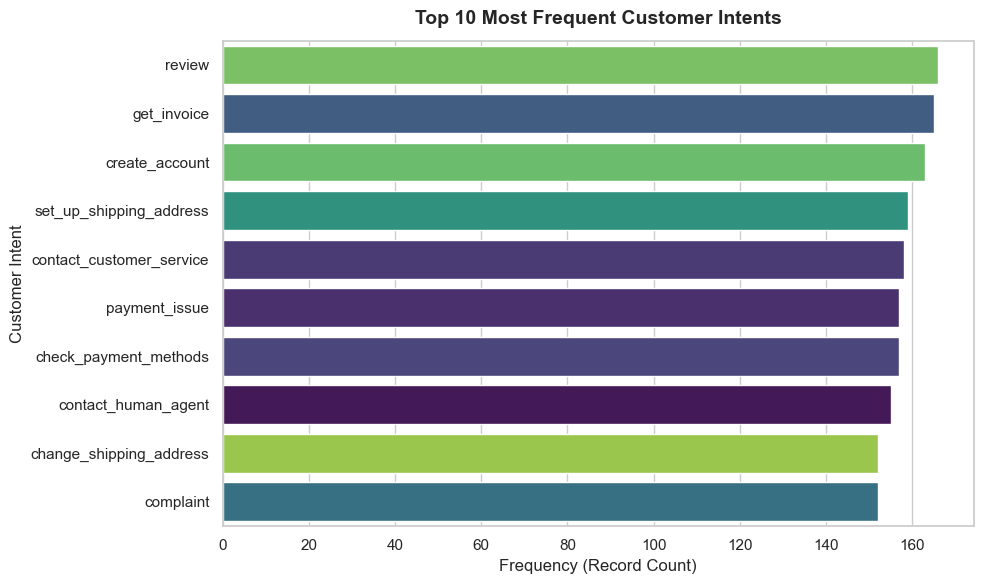

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Determine top 10 most frequent customer intents
top_10_intents = df_clean['intent'].value_counts().head(10)
most_freq_intent = top_10_intents.index[0]
most_freq_count = top_10_intents.iloc[0]
dominance_ratio = (most_freq_count / len(df_clean)) * 100

print(f"Most frequent intent: '{most_freq_intent}' ({most_freq_count} records, {dominance_ratio:.2f}% of data)")
print(f"Severe class imbalance check: Top intent is {dominance_ratio:.2f}% (< 80% threshold). Class balance is healthy.")

# 2. Plot horizontal bar chart
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean,
    y='intent',
    order=top_10_intents.index,
    hue='intent',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Most Frequent Customer Intents', fontsize=14, fontweight='bold', pad=12)

plt.xlabel('Frequency (Record Count)', fontsize=12)
plt.ylabel('Customer Intent', fontsize=12)
plt.tight_layout()
plt.show()


#### **1.3.2 Perform Bivariate Analysis [2 marks]**
**The Task:** Read the text from the uploaded Markdown SOP files and fit a `TfidfVectorizer` (with `stop_words='english'`) to transform them into vectors.

**Hints & Tips:**
* Read files into a list of strings first using `open(f, 'r').read()`.
* `TfidfVectorizer(stop_words="english")` removes common words, keeping meaningful terms.
* The resulting matrix shape should be `(num_docs, num_unique_terms)`.

**Learner Inference:** This transforms raw text into math, letting you prove whether your policies are distinct enough for an AI to tell apart.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Read text from the corporate policy Markdown files
doc_texts = []
doc_names = []

for fpath in md_files:
    with open(fpath, 'r', encoding='utf-8') as f:
        doc_texts.append(f.read())
    doc_names.append(os.path.basename(fpath).replace('.md', ''))

print(f"Loaded {len(doc_texts)} SOP documents for TF-IDF vectorization:")
for name, text in zip(doc_names, doc_texts):
    print(f"  - {name:28s} : {len(text):5d} characters, {len(text.split()):4d} words")

# 2. Fit TfidfVectorizer with English stop words
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf_vectorizer.fit_transform(doc_texts)

# 3. Inspect TF-IDF matrix properties
num_docs, num_vocab = tfidf_matrix.shape
print(f"\nTF-IDF Matrix Shape: ({num_docs}, {num_vocab}) -> {num_docs} documents and {num_vocab} unique vocabulary terms.")


Loaded 13 SOP documents for TF-IDF vectorization:
  - account_recovery             :  1553 characters,  240 words
  - billing_disputes             :  1661 characters,  250 words
  - data_privacy                 :  1721 characters,  254 words
  - escalation_matrix            :  1550 characters,  234 words
  - order_tracking               :  1534 characters,  245 words
  - password_reset               :  1604 characters,  258 words
  - payment_methods              :  1629 characters,  255 words
  - product_return               :  1570 characters,  243 words
  - refund_policy                :  1742 characters,  280 words
  - shipping_delays              :  1542 characters,  247 words
  - subscription_cancellation    :  1562 characters,  233 words
  - technical_troubleshooting    :  1646 characters,  246 words
  - working_hours                :  1521 characters,  228 words

TF-IDF Matrix Shape: (13, 797) -> 13 documents and 797 unique vocabulary terms.


#### **1.3.3 Generate Visualisations [2 marks]**
**The Task:** Calculate cosine similarity between the TF-IDF vectors of the SOP documents and plot an annotated heatmap.

**Hints & Tips:**
* Use `cosine_similarity` from sklearn and `sns.heatmap` with `annot=True`.
* Diagonal should always be 1.0 (document vs itself).
* Off-diagonal >0.5 = high overlap (RAG may struggle); <0.3 = low overlap (good retrieval).

**Learner Inference:** High overlap (dark off-diagonal squares) means the RAG system struggles to fetch the right doc. Low overlap proves retrieval will be accurate.

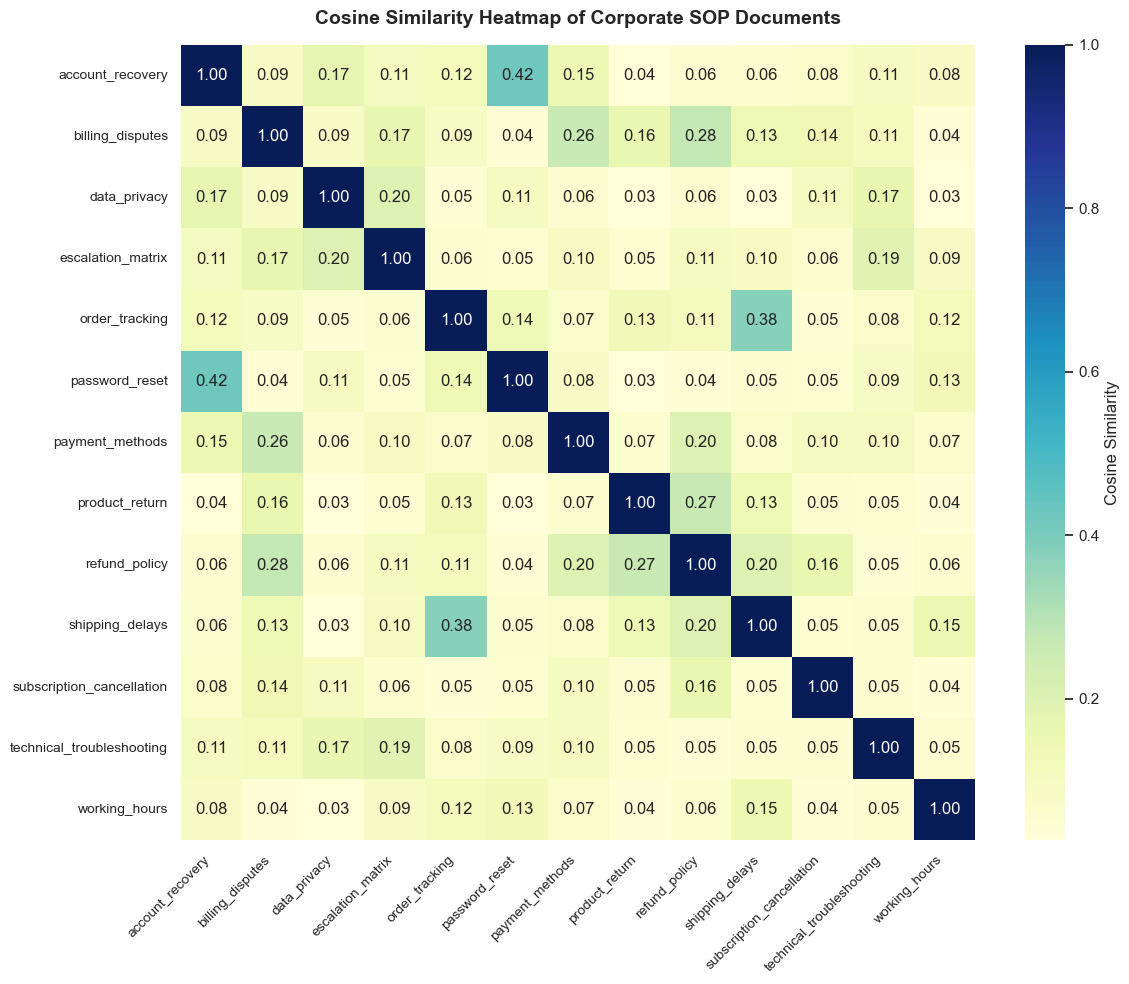

--- Corporate Policy Overlap Inferences ---
Self-similarity on diagonal: 1.00 (strictly 1.0 for all docs)
Average off-diagonal similarity: 0.106
Maximum off-diagonal similarity: 0.424

Learner Inference: Low average cross-document similarity (< 0.30) confirms clear semantic separation among SOP policies. RAG retrieval will effectively distinguish policies with minimal topical confusion.


In [6]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Calculate pairwise cosine similarity between document vectors
cosine_sim_matrix = cosine_similarity(tfidf_matrix)

# 2. Plot annotated heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    cosine_sim_matrix,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    xticklabels=doc_names,
    yticklabels=doc_names,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('Cosine Similarity Heatmap of Corporate SOP Documents', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# 3. Overlap and Retrieval Separability Inferences
diag_mask = ~np.eye(len(doc_names), dtype=bool)
off_diag = cosine_sim_matrix[diag_mask]
mean_sim = off_diag.mean()
max_sim = off_diag.max()

print("--- Corporate Policy Overlap Inferences ---")
print(f"Self-similarity on diagonal: {np.diag(cosine_sim_matrix).min():.2f} (strictly 1.0 for all docs)")
print(f"Average off-diagonal similarity: {mean_sim:.3f}")
print(f"Maximum off-diagonal similarity: {max_sim:.3f}")

if mean_sim < 0.30:
    print("\nLearner Inference: Low average cross-document similarity (< 0.30) confirms clear semantic separation among SOP policies. RAG retrieval will effectively distinguish policies with minimal topical confusion.")
else:
    print("\nLearner Inference: Moderate cross-document similarity observed. RAG retrieval will benefit from precise query routing or chunk re-ranking to disambiguate closely related policies.")


---
## Save Artifacts for Notebook 2

**IMPORTANT:** This cell saves the cleaned DataFrame. Notebook 2 depends on this file.

In [7]:
# Save the cleaned DataFrame to sampled_data.csv (required by Notebook 2)
output_filename = "sampled_data.csv"

# Primary destination in current working directory
df_clean.to_csv(output_filename, index=False)
print(f"Successfully saved {len(df_clean)} records to '{output_filename}'")

# Also save copies to root and Files/Dataset for cross-directory accessibility
extra_paths = [
    os.path.join("..", output_filename),
    os.path.join("..", "..", output_filename),
    os.path.join("..", "Dataset", output_filename),
    os.path.join("Files", "Notebook", output_filename),
    os.path.join("Files", "Dataset", output_filename)
]
for p in extra_paths:
    parent = os.path.dirname(p)
    if parent and os.path.exists(parent):
        df_clean.to_csv(p, index=False)
        print(f"Saved copy to: {p}")

# Validate saved file
df_saved = pd.read_csv(output_filename)
print(f"\nVerification check: Read back '{output_filename}' -> Shape: {df_saved.shape}")
print(f"Columns: {list(df_saved.columns)}")


Successfully saved 3902 records to 'sampled_data.csv'
Saved copy to: ..\sampled_data.csv
Saved copy to: ..\..\sampled_data.csv


Saved copy to: ..\Dataset\sampled_data.csv



Verification check: Read back 'sampled_data.csv' -> Shape: (3902, 5)
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 2.**

- [ ] Bitext dataset loaded and `.info()` printed
- [ ] Dataset sampled to 4000 rows (or chosen size 1000–5000)
- [ ] Nulls inspected, near-duplicates removed via normalised dedup
- [ ] Top 10 intent bar chart rendered
- [ ] TF-IDF vectorisation completed on SOP documents
- [ ] Cosine similarity heatmap rendered
- [ ] **`sampled_data.csv` saved to disk** ← _CRITICAL for Notebook 2_
- [ ] `corporate_policies/` folder still accessible ← _Needed in Notebooks 2 and 4_

**If any item is unchecked, fix it before moving on.**